# LLM-prompts Topic Classification

In [ ]:
!pip install -q datasets transformers scikit-learn torch

In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

## Load Split dataset

In [ ]:
# Load dataset
dataset = load_dataset("maryamdar/topic_classification_dataset_gen")

In [ ]:
dataset["train"] = dataset["train"].filter(lambda x: x["use_for_train"] is True)

In [ ]:
dataset["train"] = dataset["train"].filter(
    lambda x: x["generator_model"] != "MiMo V2.5 Free"
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "BAAI/bge-small-en-v1.5"
# model_name = 	"BAAI/bge-large-en"
# model_name = "google/embeddinggemma-300m"



In [ ]:
LABEL_ORDER = [
    "Desktop & Mobile & Web Development",
    "Cybersecurity",
    "AI / Machine Learning / Data Science",
    "Infrastructure (DevOps, Cloud, Databases, Networking)",
    "Clinical Diagnosis, Treatment & Surgery",
    "Medication & Pharmacology",
    "Mental Health",
    "Healthcare Organizations, System, Hospitals",
    "Nutrition",
    "Payments & Personal Budgeting",
    "Investment, Markets & Cryptocurrency",
    "Corporate",
    "Physics, Mathematics",
    "Chemistry",
    "Biology",
    "Team Sports",
    "Individual Sports",
    "Fitness",
    "Civil, Structural & Architecture",
    "Mechanical & Electrical Engineering",
    "Family & Relationships",
    "Personal",
    "Travel",
    "Marketing & Sales",
    "Entrepreneurship & Startups",
    "Management & Strategy & Human Resources",
    "Criminal Law",
    "Family Law",
    "Corporate Law",
    "Civil Law" ,
    "Game",
    "Film",
    "Music",
    "Literature",
    "Painting",
]

In [ ]:
# Parent-to-Child Mapping Hierarchy
HIERARCHY = {
    "Programming / Technology": [
        "Desktop & Mobile & Web Development",
        "Cybersecurity",
        "AI / Machine Learning / Data Science",
        "Infrastructure (DevOps, Cloud, Databases, Networking)"
    ],
    "Medical": [
        "Clinical Diagnosis, Treatment & Surgery",
        "Medication & Pharmacology",
        "Mental Health",
        "Healthcare Organizations, System, Hospitals",
        "Nutrition"
    ],
    "Finance": [
        "Payments & Personal Budgeting",
        "Investment, Markets & Cryptocurrency",
        "Corporate"
    ],
    "Science": [
        "Physics, Mathematics",
        "Chemistry",
        "Biology"
    ],
    "Sports": [
        "Team Sports",
        "Individual Sports",
        "Fitness"
    ],
    "Engineering": [
        "Civil, Structural & Architecture",
        "Mechanical & Electrical Engineering",
    ],
    "Personal": [
        "Family & Relationships",
        "Personal",
        "Travel"
    ],
    "Business": [
        "Marketing & Sales",
        "Entrepreneurship & Startups",
        "Management & Strategy & Human Resources"
    ],
     "Law": [
        "Criminal Law",
        "Family Law",
        "Corporate Law",
        "Civil Law"
    ],
     "Art": [
        "Game",
        "Film",
        "Music",
        "Literature",
        "Painting"
    ],


}

# Invert mapping to find a parent from any child label
CHILD_TO_PARENT = {}
for parent, children in HIERARCHY.items():
    for child in children:
        CHILD_TO_PARENT[child] = parent

In [ ]:
import pandas as pd

df = dataset["train"].to_pandas()

print("--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Missing (Null) Values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

# Duplicate Text Entries
duplicate_texts = df.duplicated(subset=['text']).sum()
print("--- Duplicates ---")
print(f"Number of exact duplicate text rows: {duplicate_texts}")
print(f"Percentage of duplicates: {(duplicate_texts / len(df)) * 100:.2f}%")
print("\n" + "="*40 + "\n")

# Class Distribution (Rows per Label)
print("--- All Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Dataset Info ---
Total Rows: 19935
Columns: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train']

--- Missing Values ---
text                    0
old_label           12642
old_parent_label    12642
generator_model         0
source                  0
generation_group     2983
label                   0
parent_label            0
use_for_train           0
dtype: int64


--- Duplicates ---
Number of exact duplicate text rows: 0
Percentage of duplicates: 0.00%


--- All Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1315    6.596438
                                        Cybersecurity   1013    5.081515
                                        Mental Health   1003    5.031352
          Healthcare Organizations, System, Hospitals    943    4.730374
                 AI / Machine Learning / Data Science    837    

In [ ]:
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'], keep='first')

In [ ]:
print(f"Total Unique Labels: {len(LABEL_ORDER)}")
print(f"All Label Names: {LABEL_ORDER}\n")

print("=" * 50)
print("--- 3 EXAMPLES PER LABEL ---")
print("=" * 50)

for label_name in LABEL_ORDER:
    print(f"\n🏷️  LABEL: {label_name}")
    print("-" * 40)

    samples = df[df["label"] == label_name]["text"].head(3)

    if len(samples) == 0:
        print("(No examples)")
        continue

    for i, example in enumerate(samples, 1):
        clean_text = example.replace("\n", " ")
        if len(clean_text) > 150:
            print(f"[{i}] {clean_text[:150]}...")
        else:
            print(f"[{i}] {clean_text}")

Total Unique Labels: 35
All Label Names: ['Desktop & Mobile & Web Development', 'Cybersecurity', 'AI / Machine Learning / Data Science', 'Infrastructure (DevOps, Cloud, Databases, Networking)', 'Clinical Diagnosis, Treatment & Surgery', 'Medication & Pharmacology', 'Mental Health', 'Healthcare Organizations, System, Hospitals', 'Nutrition', 'Payments & Personal Budgeting', 'Investment, Markets & Cryptocurrency', 'Corporate', 'Physics, Mathematics', 'Chemistry', 'Biology', 'Team Sports', 'Individual Sports', 'Fitness', 'Civil, Structural & Architecture', 'Mechanical & Electrical Engineering', 'Family & Relationships', 'Personal', 'Travel', 'Marketing & Sales', 'Entrepreneurship & Startups', 'Management & Strategy & Human Resources', 'Criminal Law', 'Family Law', 'Corporate Law', 'Civil Law', 'Game', 'Film', 'Music', 'Literature', 'Painting']

--- 3 EXAMPLES PER LABEL ---

🏷️  LABEL: Desktop & Mobile & Web Development
----------------------------------------
[1] react query cache invalid

## Label encoding

In [ ]:
from datasets import Dataset

# Fixed mapping
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

# Encode labels
df["label_id"] = df["label"].map(label_to_id)

# Safety check
if df["label_id"].isna().any():
    missing = df[df["label_id"].isna()]["label"].unique()
    raise ValueError(f"Unknown labels found: {missing}")

print("Label Map:")
print(id_to_label)

# Convert back to HF Dataset
clean_dataset = Dataset.from_pandas(df, preserve_index=False)

Label Map:
{0: 'Desktop & Mobile & Web Development', 1: 'Cybersecurity', 2: 'AI / Machine Learning / Data Science', 3: 'Infrastructure (DevOps, Cloud, Databases, Networking)', 4: 'Clinical Diagnosis, Treatment & Surgery', 5: 'Medication & Pharmacology', 6: 'Mental Health', 7: 'Healthcare Organizations, System, Hospitals', 8: 'Nutrition', 9: 'Payments & Personal Budgeting', 10: 'Investment, Markets & Cryptocurrency', 11: 'Corporate', 12: 'Physics, Mathematics', 13: 'Chemistry', 14: 'Biology', 15: 'Team Sports', 16: 'Individual Sports', 17: 'Fitness', 18: 'Civil, Structural & Architecture', 19: 'Mechanical & Electrical Engineering', 20: 'Family & Relationships', 21: 'Personal', 22: 'Travel', 23: 'Marketing & Sales', 24: 'Entrepreneurship & Startups', 25: 'Management & Strategy & Human Resources', 26: 'Criminal Law', 27: 'Family Law', 28: 'Corporate Law', 29: 'Civil Law', 30: 'Game', 31: 'Film', 32: 'Music', 33: 'Literature', 34: 'Painting'}


## Train/Test Split

### Train and Test split of one dataset

In [ ]:
from datasets import ClassLabel

# Get the number of unique classes
num_classes = len(df['label_id'].unique())

# Cast 'label_id' to ClassLabel type
clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# Now the stratified split will work smoothly
split_dataset = clean_dataset.train_test_split(
    test_size=0.2,
    stratify_by_column="label_id",
    seed=42
)

train_ds = split_dataset["train"]
test_ds = split_dataset["test"]
print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

Casting the dataset:   0%|          | 0/19935 [00:00<?, ? examples/s]

Train samples: 15948 | Test samples: 3987


### Different Train dataset and Test dataset

In [ ]:
# from datasets import ClassLabel

# # Get the number of unique classes
# num_classes = len(df['label_id'].unique())

# # Cast 'label_id' to ClassLabel type
# clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# # Use the entire clean_dataset for training
# train_ds = clean_dataset
# print(f"Train samples: {len(train_ds)}")

### Loading and Preparing the New Test Dataset

In [ ]:
# # Load the new test dataset from Hugging Face
# # Assuming the dataset to load is 'maryamdar/topic_classification_dataset_gen' and you want the 'test' split
# new_test_dataset = load_dataset("maryamdar/topic-classification-dataset-real-labeled", split="train")

# # Filter out rows where the label is 'Not Related'
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Not Related")
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Ambiguous")

# #other filters
# # new_test_dataset = new_test_dataset.filter(
# #     lambda x: x["confidence_score"] >= 0.9
# # )
# # new_test_dataset = new_test_dataset.filter(lambda x: x["source_dataset"] != "lavita/medical-qa-datasets")


# # Convert to pandas DataFrame for label encoding
# df_test = new_test_dataset.to_pandas()

# # Encode labels using the existing label_to_id mapping
# df_test["label_id"] = df_test["label"].map(label_to_id)

# # Safety check for unknown labels in the new test set
# if df_test["label_id"].isna().any():
#     missing = df_test[df_test["label_id"].isna()]["label"].unique()
#     print(f"Warning: Unknown labels found in the new test dataset: {missing}. These will be dropped.")
#     df_test = df_test.dropna(subset=["label_id"])

# # Convert back to Hugging Face Dataset and cast label_id
# test_ds = Dataset.from_pandas(df_test, preserve_index=False)
# test_ds = test_ds.cast_column("label_id", ClassLabel(num_classes=num_classes))

# print(f"New Test samples: {len(test_ds)}")

### train and test class distribution

In [ ]:
train_ds[0]

{'text': 'Why should an access token have a short lifetime?',
 'old_label': None,
 'old_parent_label': None,
 'generator_model': 'GPT-5.6 Luna',
 'source': 'generated',
 'generation_group': 'second_label_desc_parent',
 'label': 'Cybersecurity',
 'parent_label': 'Programming / Technology',
 'use_for_train': True,
 'label_id': 1}

In [ ]:
import pandas as pd
df = train_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Train Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Train Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1052    6.596438
                                        Cybersecurity    810    5.079007
                                        Mental Health    802    5.028844
          Healthcare Organizations, System, Hospitals    754    4.727866
                 AI / Machine Learning / Data Science    670    4.201154
              Clinical Diagnosis, Treatment & Surgery    633    3.969150
Infrastructure (DevOps, Cloud, Databases, Networking)    607    3.806120
                 Investment, Markets & Cryptocurrency    556    3.486331
                            Medication & Pharmacology    539    3.379734
                                            Nutrition    472    2.959619
                                                Music    463    2.903185
                                              Fitness    437    2.740156
                        

In [ ]:
import pandas as pd
df = test_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Test Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Test Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development    263    6.596438
                                        Cybersecurity    203    5.091548
                                        Mental Health    201    5.041384
          Healthcare Organizations, System, Hospitals    189    4.740406
                 AI / Machine Learning / Data Science    167    4.188613
              Clinical Diagnosis, Treatment & Surgery    158    3.962879
Infrastructure (DevOps, Cloud, Databases, Networking)    152    3.812390
                 Investment, Markets & Cryptocurrency    139    3.486331
                            Medication & Pharmacology    135    3.386005
                                            Nutrition    118    2.959619
                                                Music    116    2.909456
                                              Fitness    109    2.733885
                         

## Preprocessing & Embeddings

In [ ]:
# mean pooling helper
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
# Batch processing function
def extract_embeddings(batch):
    encoded_input = tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        model_output = model(**encoded_input)

    sentence_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
    sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)

    return {"embedding": sentence_embeddings.cpu().numpy()}

In [ ]:
# embedding extraction
train_embedded = train_ds.map(extract_embeddings, batched=True, batch_size=32)
test_embedded = test_ds.map(extract_embeddings, batched=True, batch_size=32)

Map:   0%|          | 0/15948 [00:00<?, ? examples/s]

Map:   0%|          | 0/3987 [00:00<?, ? examples/s]

In [ ]:
# Convert features and target labels into numpy arrays
X_train = np.array(train_embedded["embedding"])
y_train = np.array(train_embedded["label_id"])

X_test = np.array(test_embedded["embedding"])
y_test = np.array(test_embedded["label_id"])

In [ ]:
y_train[0]

np.int64(1)

In [ ]:
X_train[0].shape

(384,)

## Train Classifier

In [ ]:
classifier = LogisticRegression(max_iter=1000, C=1.0)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import SGDClassifier
# from sklearn.metrics import log_loss, accuracy_score

# # ============================================================
# # MODEL
# # ============================================================

# classifier = SGDClassifier(
#     loss="log_loss",       # Logistic Regression
#     max_iter=1,            # We manually control epochs
#     learning_rate="optimal",
#     random_state=42
# )

# # ============================================================
# # TRAINING
# # ============================================================

# EPOCHS =

# train_losses = []
# train_accuracies = []

# classes = np.unique(y_train)

# for epoch in range(EPOCHS):

#     # Shuffle data every epoch
#     indices = np.random.permutation(len(X_train))

#     X_epoch = X_train[indices]
#     y_epoch = y_train.iloc[indices] if hasattr(y_train, "iloc") else y_train[indices]

#     # One epoch
#     classifier.partial_fit(
#         X_epoch,
#         y_epoch,
#         classes=classes
#     )

#     # --------------------------------------------------------
#     # Predictions
#     # --------------------------------------------------------

#     y_train_pred = classifier.predict(X_train)
#     y_train_prob = classifier.predict_proba(X_train)

#     # --------------------------------------------------------
#     # Metrics
#     # --------------------------------------------------------

#     loss = log_loss(
#         y_train,
#         y_train_prob,
#         labels=classes
#     )

#     accuracy = accuracy_score(
#         y_train,
#         y_train_pred
#     )

#     train_losses.append(loss)
#     train_accuracies.append(accuracy)

#     print(
#         f"Epoch {epoch + 1:02d}/{EPOCHS} | "
#         f"Loss: {loss:.4f} | "
#         f"Accuracy: {accuracy:.4f}"
#     )

# # ============================================================
# # PLOTS
# # ============================================================

# epochs = range(1, EPOCHS + 1)

# plt.figure(figsize=(10, 5))
# plt.plot(epochs, train_losses, marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Training Loss")
# plt.title("Training Loss per Epoch")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.plot(epochs, train_accuracies, marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Training Accuracy")
# plt.title("Training Accuracy per Epoch")
# plt.grid(True)
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import SGDClassifier
# from sklearn.metrics import log_loss, accuracy_score

# # ============================================================
# # MODEL
# # ============================================================

# classifier = SGDClassifier(
#     loss="log_loss",       # Logistic Regression
#     learning_rate="optimal",
#     max_iter=1,
#     random_state=42
# )

# # ============================================================
# # CONFIG
# # ============================================================

# EPOCHS = 30

# train_losses = []
# train_accuracies = []

# val_losses = []
# val_accuracies = []

# classes = np.unique(y_train)

# # ============================================================
# # TRAIN
# # ============================================================

# for epoch in range(EPOCHS):

#     # Shuffle training data
#     indices = np.random.permutation(len(X_train))

#     X_epoch = X_train[indices]

#     if hasattr(y_train, "iloc"):
#         y_epoch = y_train.iloc[indices]
#     else:
#         y_epoch = y_train[indices]

#     # --------------------------------------------------------
#     # Train for ONE epoch
#     # --------------------------------------------------------

#     classifier.partial_fit(
#         X_epoch,
#         y_epoch,
#         classes=classes
#     )

#     # ========================================================
#     # TRAINING METRICS
#     # ========================================================

#     y_train_pred = classifier.predict(X_train)
#     y_train_prob = classifier.predict_proba(X_train)

#     train_loss = log_loss(
#         y_train,
#         y_train_prob,
#         labels=classes
#     )

#     train_accuracy = accuracy_score(
#         y_train,
#         y_train_pred
#     )

#     # ========================================================
#     # VALIDATION METRICS
#     # ========================================================

#     y_val_pred = classifier.predict(X_test)
#     y_val_prob = classifier.predict_proba(X_test)

#     val_loss = log_loss(
#         y_test,
#         y_val_prob,
#         labels=classes
#     )

#     val_accuracy = accuracy_score(
#         y_test,
#         y_val_pred
#     )

#     # ========================================================
#     # SAVE METRICS
#     # ========================================================

#     train_losses.append(train_loss)
#     train_accuracies.append(train_accuracy)

#     val_losses.append(val_loss)
#     val_accuracies.append(val_accuracy)

#     # ========================================================
#     # PRINT
#     # ========================================================

#     print(
#         f"Epoch {epoch + 1:02d}/{EPOCHS} | "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Train Acc: {train_accuracy:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Acc: {val_accuracy:.4f}"
#     )

# # ============================================================
# # EPOCHS
# # ============================================================

# epochs = range(1, EPOCHS + 1)

# # ============================================================
# # LOSS CURVE
# # ============================================================

# plt.figure(figsize=(10, 6))

# plt.plot(
#     epochs,
#     train_losses,
#     marker="o",
#     label="Training Loss"
# )

# plt.plot(
#     epochs,
#     val_losses,
#     marker="o",
#     label="Validation Loss"
# )

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

# # ============================================================
# # ACCURACY CURVE
# # ============================================================

# plt.figure(figsize=(10, 6))

# plt.plot(
#     epochs,
#     train_accuracies,
#     marker="o",
#     label="Training Accuracy"
# )

# plt.plot(
#     epochs,
#     val_accuracies,
#     marker="o",
#     label="Validation Accuracy"
# )

# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()

## save classifier as joblib

In [ ]:
import joblib
import json

# Save trained classifier
joblib.dump(classifier, "classifier.joblib")

# Save label mappings
id_to_label = {i: label for label, i in label_to_id.items()}
with open("label_mappings.json", "w") as f:
    json.dump({"id_to_label": {str(k): v for k, v in id_to_label.items()}}, f)

## Confidence-Based Filtering Test Data

In [ ]:
# Get probability for every class
probabilities = classifier.predict_proba(X_test)

# Get the predicted class
y_pred = classifier.classes_[np.argmax(probabilities, axis=1)]

# Highest probability = confidence
confidence = np.max(probabilities, axis=1)

print("Probabilities shape:", probabilities.shape)
print("Number of test samples:", len(y_test))

Probabilities shape: (3987, 35)
Number of test samples: 3987


### Method 1 : Confidence Treshold

In [ ]:
CONFIDENCE_THRESHOLD = 0.7

# Keep only samples where the model is at least 70% confident
confident_mask = confidence >= CONFIDENCE_THRESHOLD

print(f"Total test samples: {len(y_test)}")
print(f"Confident samples: {confident_mask.sum()}")
print(f"Filtered out: {(~confident_mask).sum()}")
print(f"Coverage: {confident_mask.mean():.2%}")

Total test samples: 3987
Confident samples: 2691
Filtered out: 1296
Coverage: 67.49%


In [ ]:
# Filter true labels and predictions
y_test_filtered = y_test[confident_mask]
y_pred_filtered = y_pred[confident_mask]

print("Samples used for evaluation:", len(y_test_filtered))

Samples used for evaluation: 2691


## Method 2:  Probability Margin Filtering

In [ ]:
# Get the two highest probabilities for each sample
sorted_probabilities = np.sort(probabilities, axis=1)

top_probability = sorted_probabilities[:, -1]
second_probability = sorted_probabilities[:, -2]

# Difference between the highest and second-highest probability
probability_margin = top_probability - second_probability

MARGIN_THRESHOLD = 0.2

# Keep samples where the best class is sufficiently ahead
margin_mask = probability_margin >= MARGIN_THRESHOLD

print("\n=== Probability Margin Filtering ===")
print(f"Margin threshold: {MARGIN_THRESHOLD}")
print(f"Total test samples: {len(y_test)}")
print(f"Selected samples: {margin_mask.sum()}")
print(f"Filtered out: {(~margin_mask).sum()}")
print(f"Coverage: {margin_mask.mean():.2%}")

# Filter true labels and predictions
y_test_filtered = y_test[margin_mask]
y_pred_filtered = y_pred[margin_mask]

print("Samples used for evaluation:", len(y_test_filtered))


=== Probability Margin Filtering ===
Margin threshold: 0.2
Total test samples: 3987
Selected samples: 3595
Filtered out: 392
Coverage: 90.17%
Samples used for evaluation: 3595


## Evaluation Plots and Report


In [ ]:
def predict_model(classifier, X_test):
    return classifier.predict(X_test)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

In [ ]:
def show_classification_report(
    y_test,
    y_pred,
    label_order,
    save_report=False,
):
    label_ids = list(range(len(label_order)))

    report = classification_report(
        y_test,
        y_pred,
        labels=label_ids,
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=label_ids,
            target_names=label_order,
            zero_division=0,
        )
    )

    summary = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro F1-Score",
            "Weighted F1-Score",
        ],
        "Test": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred, average="weighted"),
        ],
    })

    summary["Test"] = summary["Test"].map("{:.2%}".format)

    display(summary)

    return report

In [ ]:
def plot_child_confusion_matrix_old(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.title("child_confusion_matrix")
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_child_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # Convert each row to percentages
    row_sums = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    ) * 100

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format=".1f",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.title("child_confusion_matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_misclassification_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="misclassification_confusion_matrix.png",
):
    # --------------------------------------------------
    # Create confusion matrix with raw counts
    # --------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # --------------------------------------------------
    # Remove correct classifications
    # --------------------------------------------------

    # Set diagonal to 0
    np.fill_diagonal(cm, 0)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_title("Misclassification Confusion Matrix")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
def show_parent_summary(report, hierarchy):
    rows = []

    for parent, children in hierarchy.items():

        precision = []
        recall = []
        f1 = []
        support = []

        for child in children:
            cls = report[child]

            precision.append(cls["precision"])
            recall.append(cls["recall"])
            f1.append(cls["f1-score"])
            support.append(cls["support"])

        rows.append({
            "Parent": parent,

            "Precision Min": min(precision),
            "Precision Avg": np.mean(precision),
            "Precision Max": max(precision),

            "Recall Min": min(recall),
            "Recall Avg": np.mean(recall),
            "Recall Max": max(recall),

            "F1 Min": min(f1),
            "F1 Avg": np.mean(f1),
            "F1 Max": max(f1),

            "Support": sum(support),
        })

    df = pd.DataFrame(rows)

    for c in df.columns:
        if c not in ["Parent", "Support"]:
            df[c] = df[c].map("{:.2%}".format)

    display(df)

In [ ]:
def plot_parent_misclassification_matrix(
    y_test,
    y_pred,
    hierarchy,
    id_to_label,
    save_path=None,
):
    # Child -> Parent mapping
    child_to_parent = {
        child: parent
        for parent, children in hierarchy.items()
        for child in children
    }

    parent_names = list(hierarchy.keys())

    # Initialize matrix
    parent_missclass_cm = pd.DataFrame(
        0,
        index=parent_names,
        columns=parent_names
    )

    # Check every child-level mistake
    for true_id, pred_id in zip(y_test, y_pred):

        true_child = id_to_label[true_id]
        pred_child = id_to_label[pred_id]

        # Ignore correct child predictions
        if true_child == pred_child:
            continue

        true_parent = child_to_parent[true_child]
        pred_parent = child_to_parent[pred_child]

        # Count this mistake at parent level
        parent_missclass_cm.loc[
            true_parent,
            pred_parent
        ] += 1


    cm = parent_missclass_cm.values


    fig_size = max(10, len(parent_names) * 0.7)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=parent_names,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xlabel(
        "Predicted Parent (from wrong child prediction)"
    )

    ax.set_ylabel(
        "True Parent (where mistake happened)"
    )

    ax.set_title(
        "Parent-Level Misclassification Matrix\n(Number of Child-Level Errors)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return parent_missclass_cm

In [ ]:
def evaluate_model(
    classifier,
    X_test,
    y_test,
    label_order,
    id_to_label,
    hierarchy,
):
    y_pred = predict_model(classifier, X_test)

    report = show_classification_report(
        y_test,
        y_pred,
        label_order,
    )
    plot_child_confusion_matrix_old(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )
    plot_misclassification_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test,
        y_pred,
        hierarchy,
        id_to_label,
    )

    return y_pred

## Evaluate Normal


--- Model Evaluation ---
Accuracy: 92.65%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.93      0.90      0.92       263
                                        Cybersecurity       0.89      0.93      0.91       203
                 AI / Machine Learning / Data Science       0.89      0.94      0.92       167
Infrastructure (DevOps, Cloud, Databases, Networking)       0.87      0.92      0.89       152
              Clinical Diagnosis, Treatment & Surgery       0.94      0.94      0.94       158
                            Medication & Pharmacology       0.91      0.95      0.93       135
                                        Mental Health       0.97      0.97      0.97       201
          Healthcare Organizations, System, Hospitals       0.95      0.98      0.96       189
                                            Nutrition       0.92      0.97      0.94       118
     

,Metric,Test
0,Accuracy,92.65%
1,Macro F1-Score,92.48%
2,Weighted F1-Score,92.64%


Saved to confusion_matrix.png


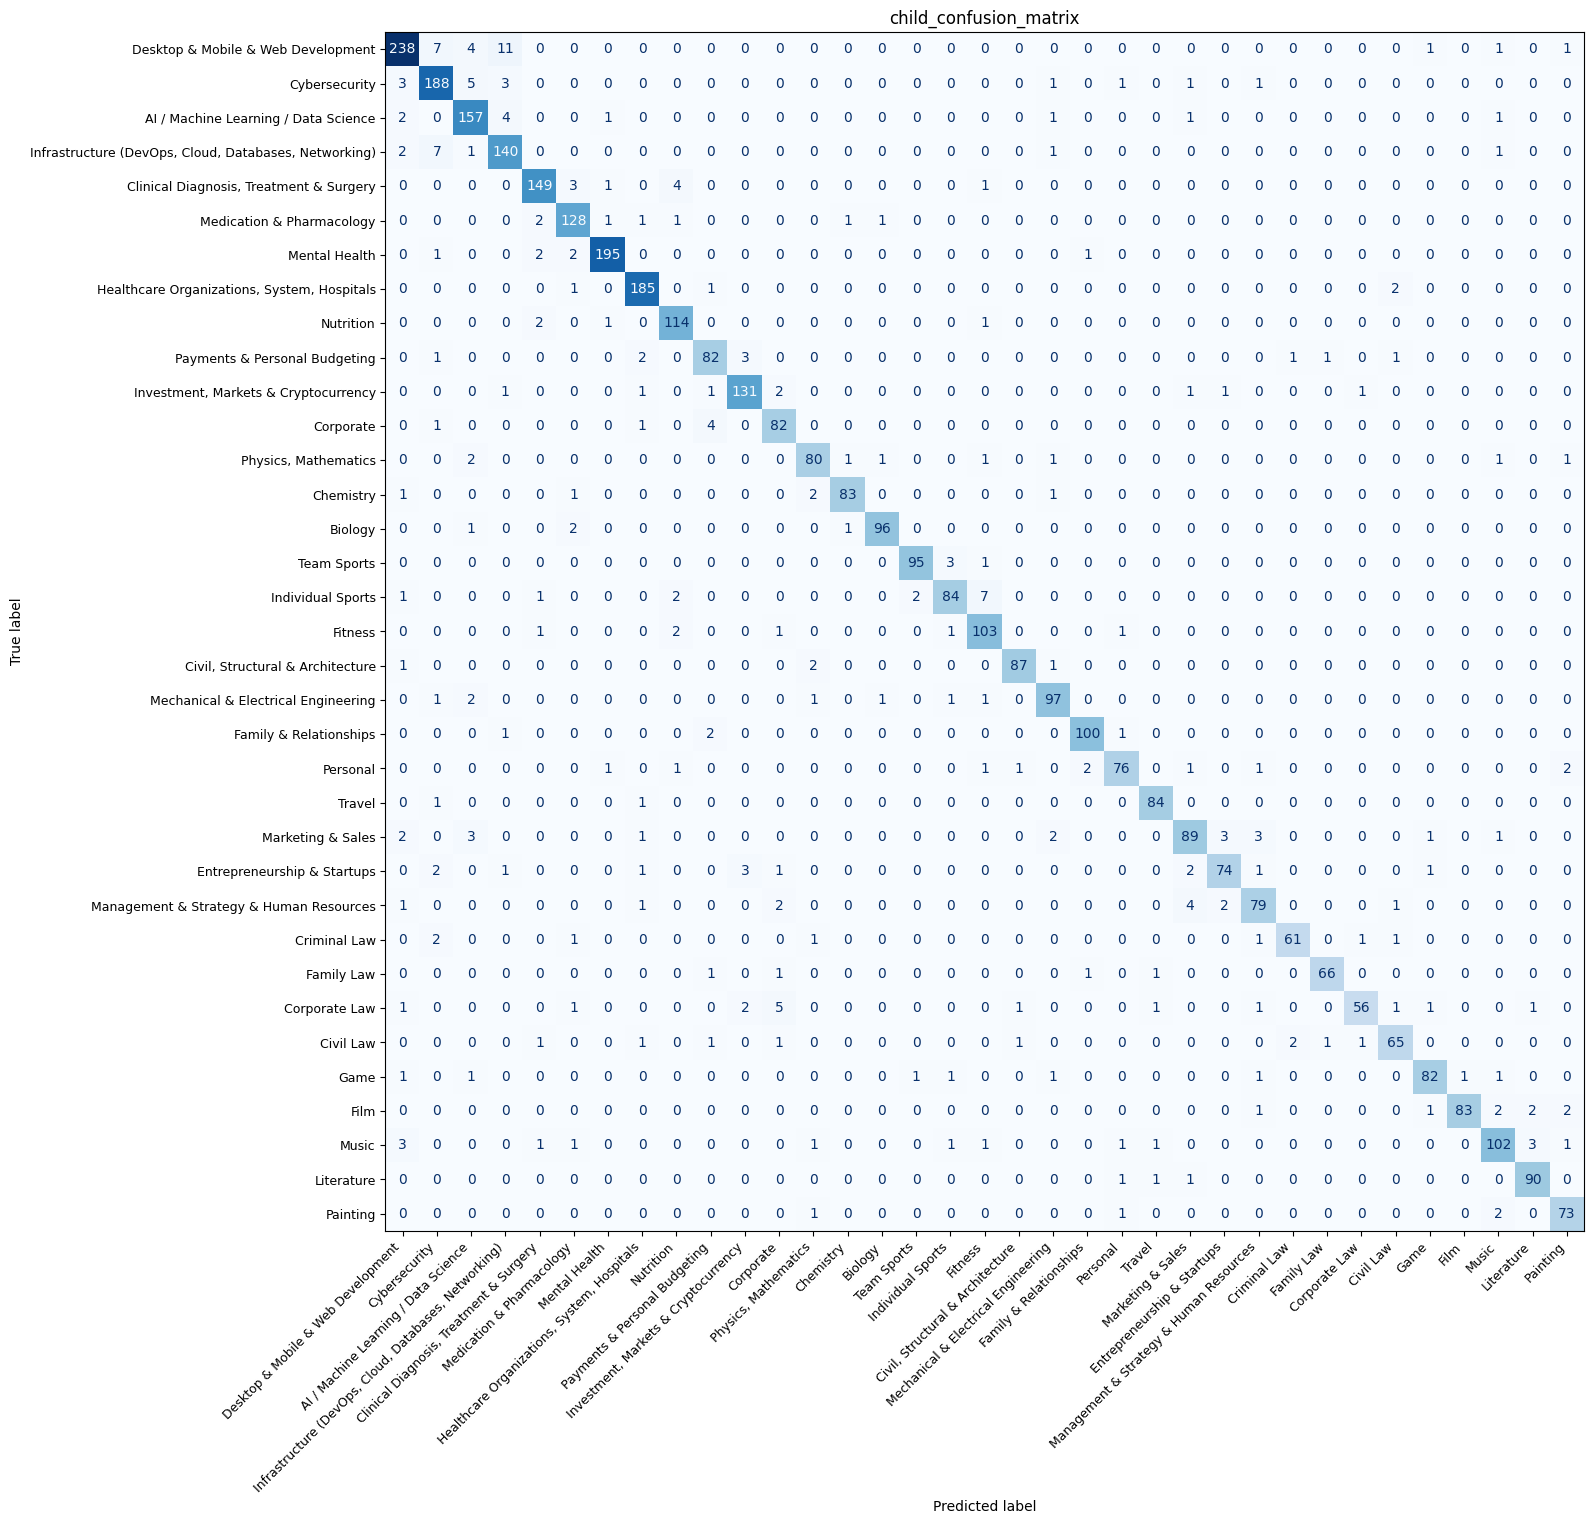

Saved to confusion_matrix.png


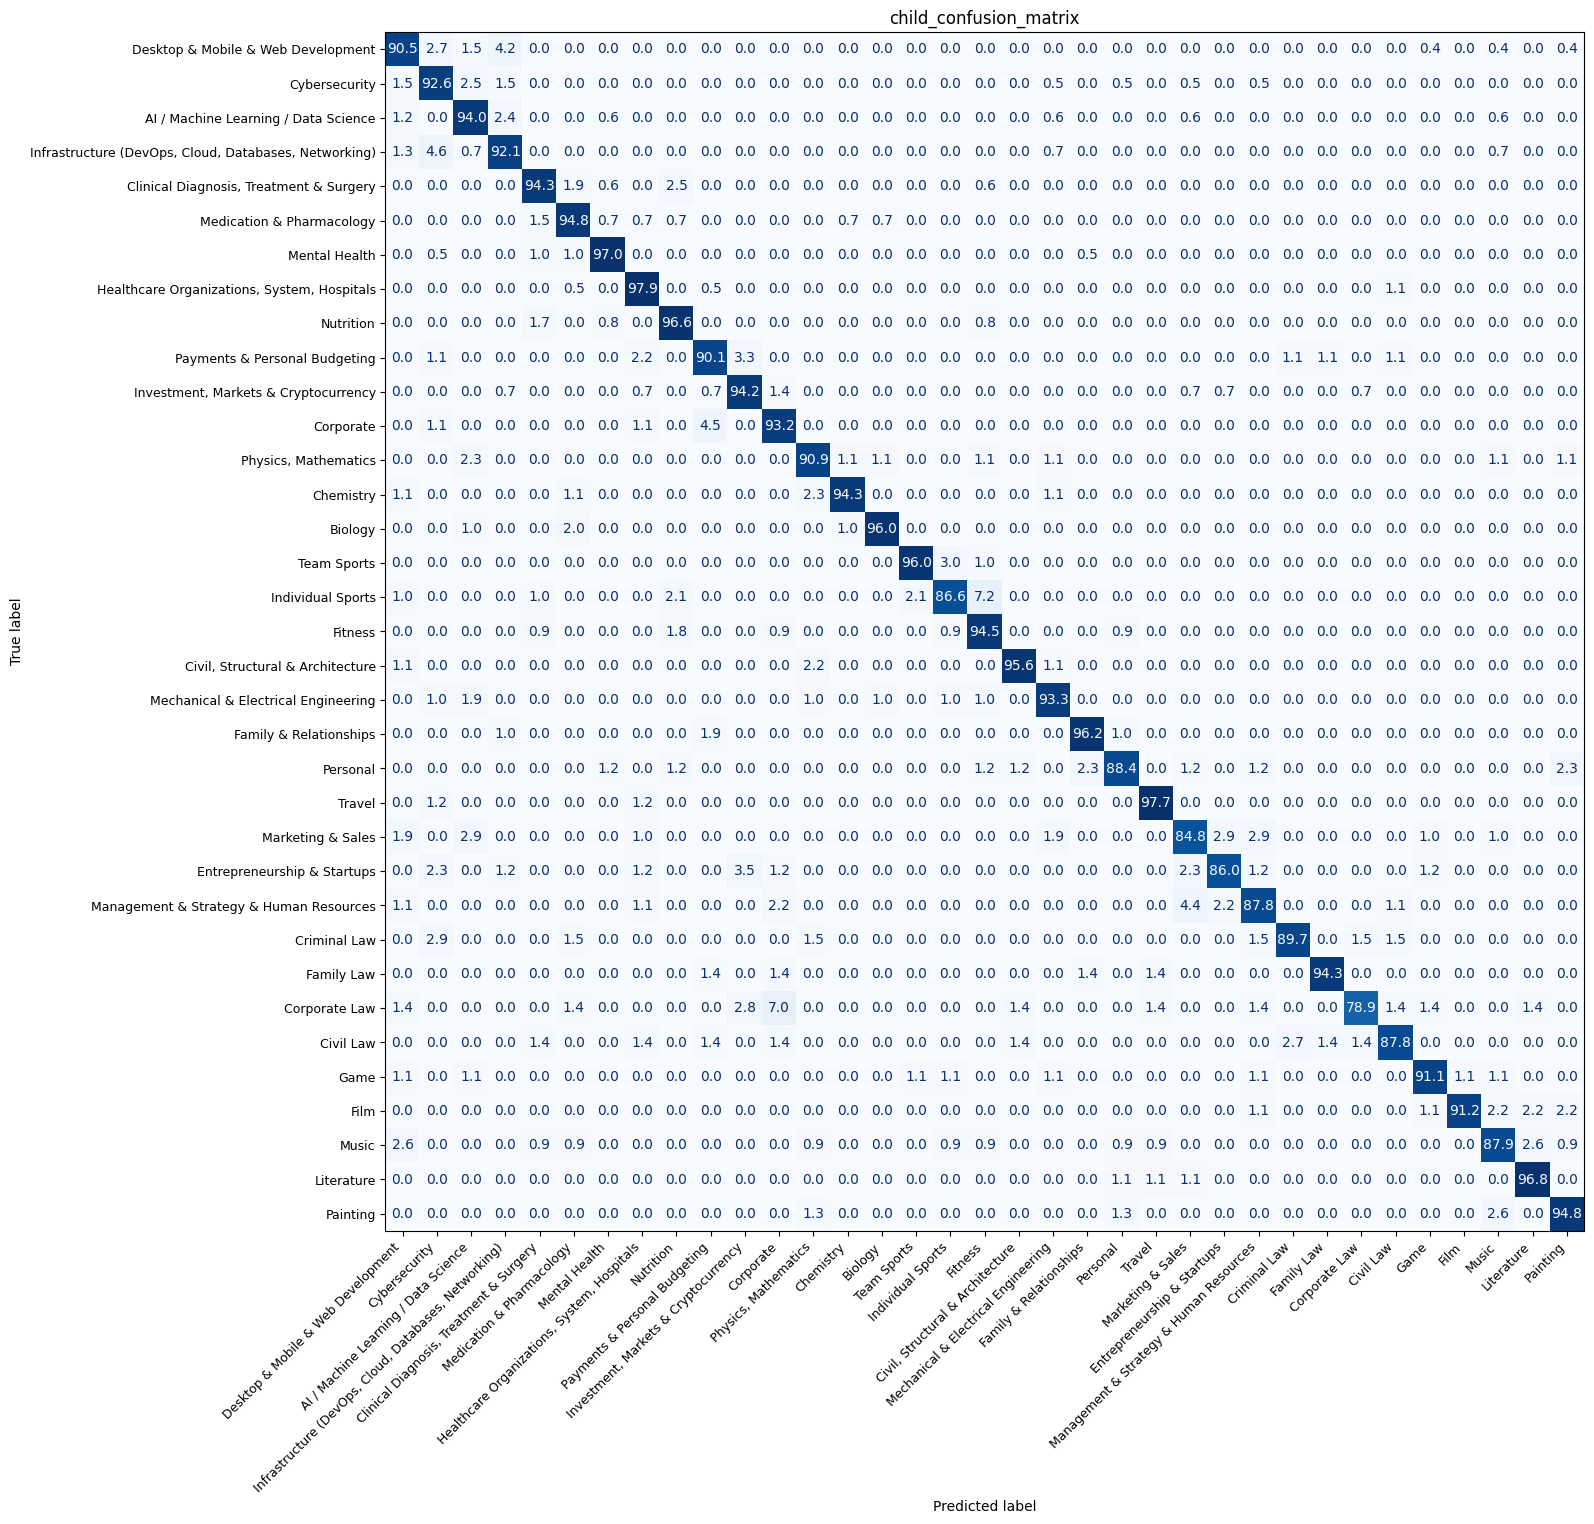

Saved to misclassification_confusion_matrix.png


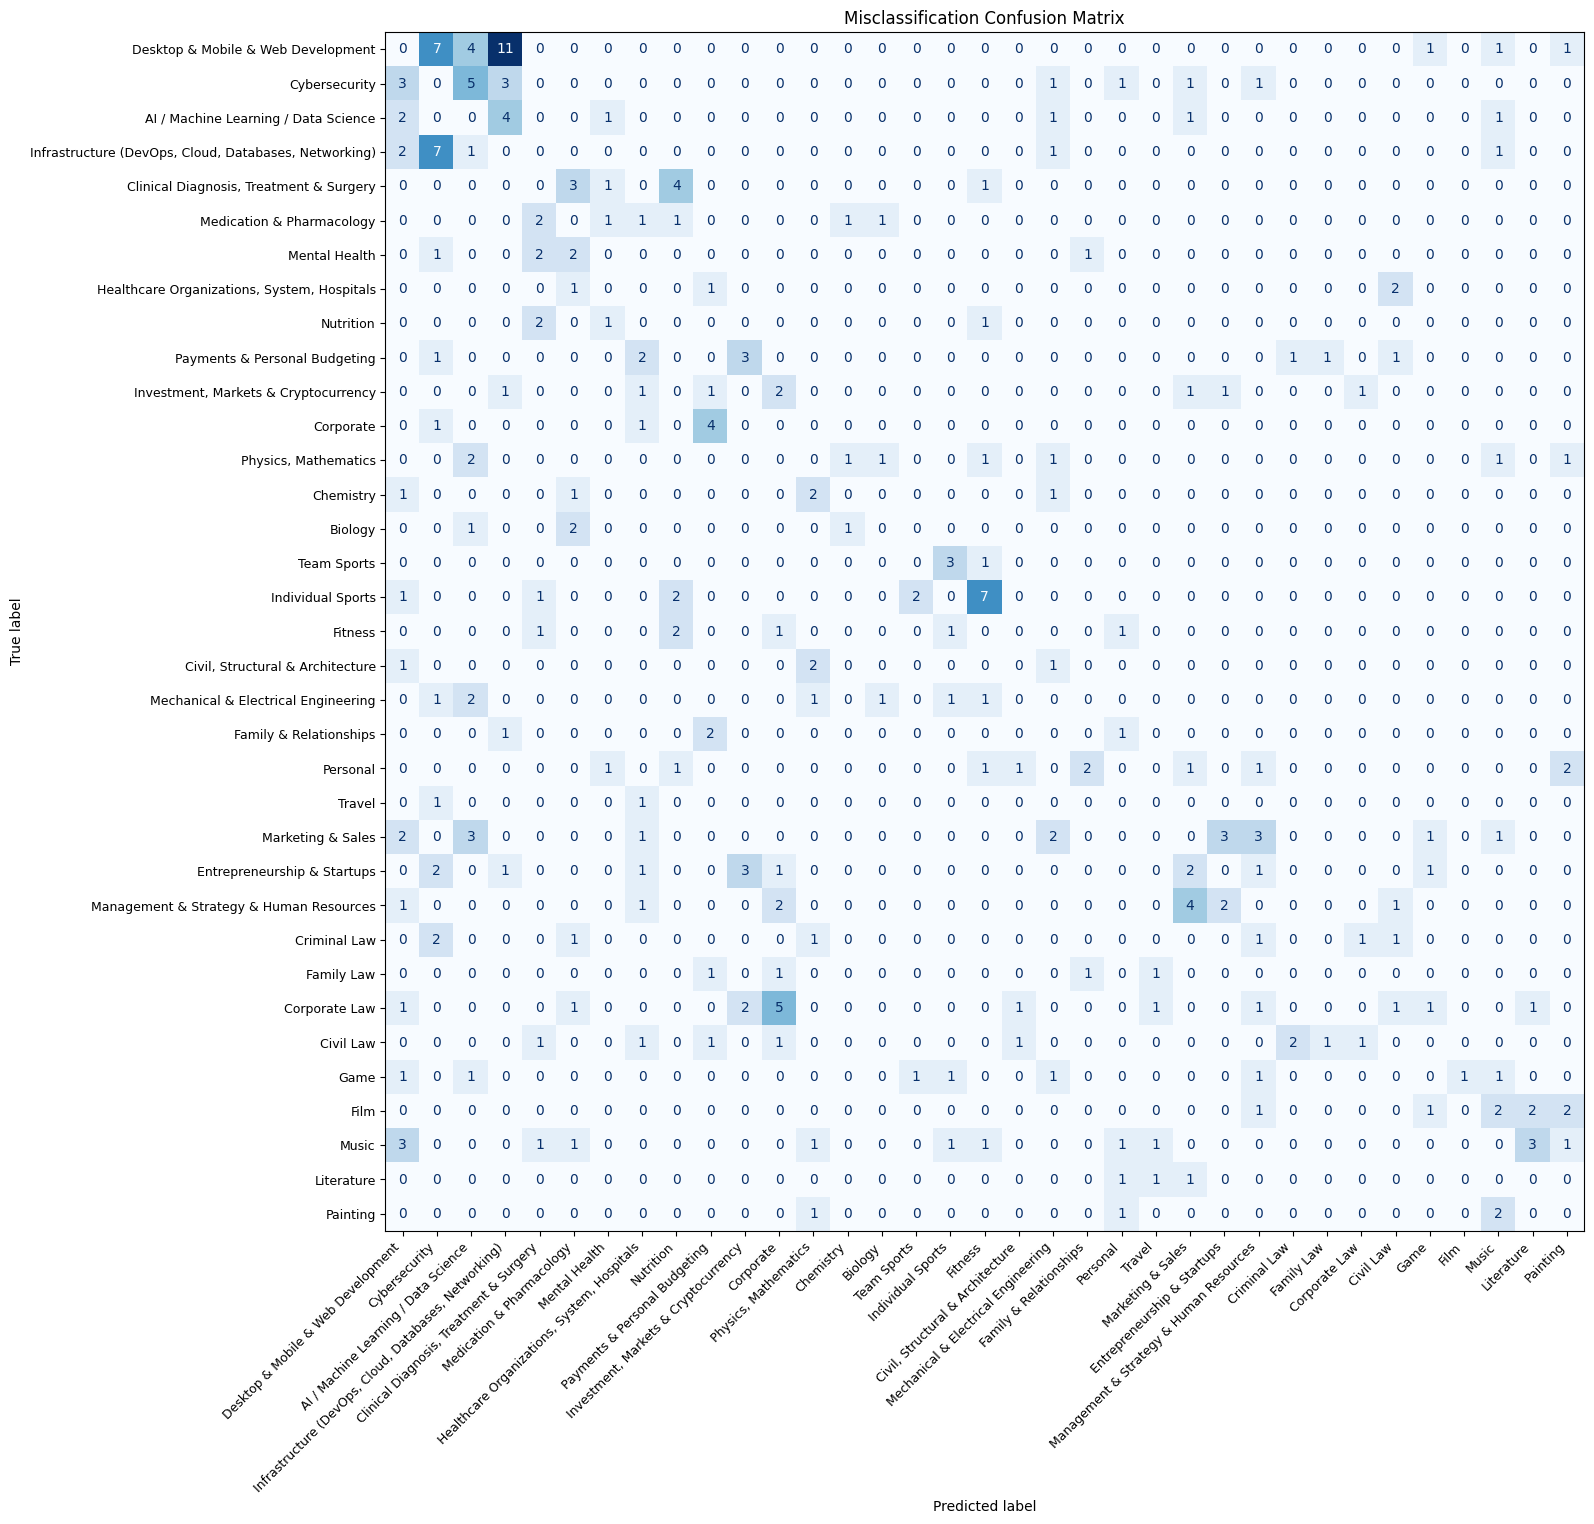

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,86.96%,89.56%,92.97%,90.49%,92.31%,94.01%,89.46%,90.88%,91.71%,785.0
1,Medical,91.43%,93.89%,97.50%,94.30%,96.13%,97.88%,93.09%,94.98%,97.26%,801.0
2,Finance,86.32%,89.90%,94.24%,90.11%,92.51%,94.24%,89.62%,91.16%,94.24%,318.0
3,Science,90.91%,94.80%,96.97%,90.91%,93.74%,96.00%,90.91%,94.26%,96.48%,276.0
4,Sports,88.03%,92.43%,96.94%,86.60%,92.35%,95.96%,89.36%,92.32%,96.45%,305.0
5,Engineering,91.51%,94.09%,96.67%,93.27%,94.44%,95.60%,92.38%,94.26%,96.13%,195.0
6,Personal,92.68%,94.76%,96.15%,88.37%,94.07%,97.67%,90.48%,94.39%,96.55%,276.0
7,Business,88.76%,90.09%,92.50%,84.76%,86.20%,87.78%,86.83%,88.08%,89.16%,281.0
8,Law,91.55%,94.71%,97.06%,78.87%,87.68%,94.29%,86.15%,90.97%,95.65%,283.0
9,Art,91.07%,93.83%,98.81%,87.93%,92.37%,96.77%,89.47%,93.04%,95.24%,467.0


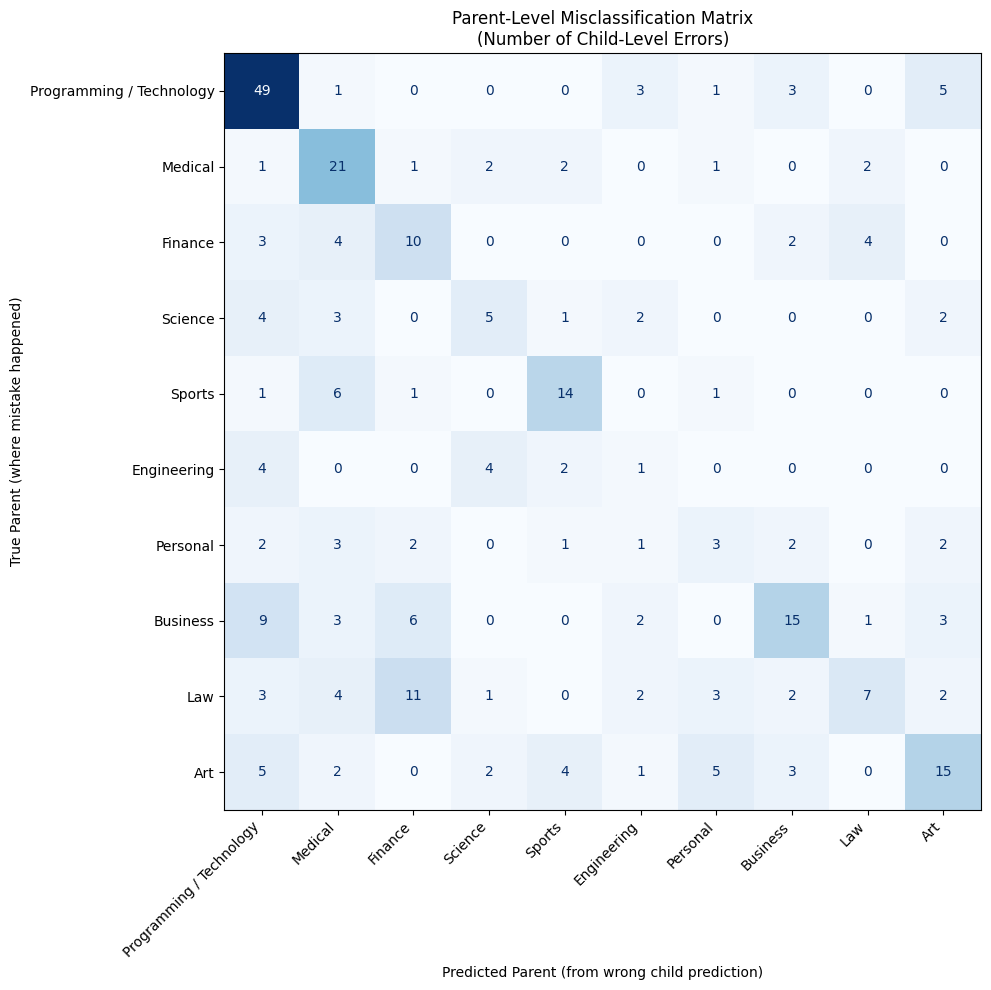

In [ ]:
y_pred = evaluate_model(
    classifier,
    X_test,
    y_test,
    LABEL_ORDER,
    id_to_label,
    HIERARCHY,
)

In [ ]:
import json
import pandas as pd


def save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
):
    # Make a copy so we don't modify the original
    df_test = df_test.copy()

    # Add predictions
    df_test["predicted_label"] = y_pred
    misclassified = df_test.copy()

    # Save ALL columns
    misclassified.to_json(
        output_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(f"Misclassified samples: {len(misclassified)}")
    print(f"Saved to: {output_path}")

    return misclassified

In [ ]:
df_test = test_ds.to_pandas()

In [ ]:
print(df_test.head())

                                                text               old_label  \
0  I've been trying to reduce my added sugar inta...               Nutrition   
1  I have nightmares, startle easily, and avoid t...                    None   
2  I'm getting married next year and my parents w...  Family & Relationships   
3  My React app has a memory leak. Every time I n...                    None   
4  I am trying to reduce the amount of single-use...                    None   

  old_parent_label                                   generator_model  \
0          Medical                                       deepseek-v4   
1             None                                      GPT-5.6 Luna   
2         Personal                                       deepseek-v4   
3             None  deepseek-ai/deepseek-v4-pro-0813/ Reason = False   
4             None  deepseek-ai/deepseek-v4-pro-0813/ Reason = False   

      source                     generation_group  \
0  generated                     

In [ ]:
save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
)

Misclassified samples: 3987
Saved to: misclassified_samples.json


,text,old_label,old_parent_label,generator_model,source,generation_group,label,parent_label,use_for_train,label_id,predicted_label
0,I've been trying to reduce my added sugar inta...,Nutrition,Medical,deepseek-v4,generated,Medical_parent,Nutrition,Medical,True,8,8
1,"I have nightmares, startle easily, and avoid t...",None,None,GPT-5.6 Luna,generated,second_label_desc_parent,Mental Health,Medical,True,6,6
2,I'm getting married next year and my parents w...,Family & Relationships,Personal,deepseek-v4,generated,10_labels_3_shuffled,Family & Relationships,Personal,True,20,20
3,My React app has a memory leak. Every time I n...,None,None,deepseek-ai/deepseek-v4-pro-0813/ Reason = False,generated,second_label_desc_single_deepseek_4,Desktop & Mobile & Web Development,Programming / Technology,True,0,0
4,I am trying to reduce the amount of single-use...,None,None,deepseek-ai/deepseek-v4-pro-0813/ Reason = False,generated,second_label_desc_single_deepseek_3,Personal,Personal,True,21,8
...,...,...,...,...,...,...,...,...,...,...,...
3982,"I take a daily statin, 40mg atorvastatin, and ...",Medication & Pharmacology,Medical,deepseek-v4,generated,Medical_parent,Medication & Pharmacology,Medical,True,5,4
3983,"The Fed just hinted at pausing rate hikes, is ...",None,None,deepseek-ai/deepseek-v4-pro-0813/ Reason = False,generated,second_label_desc_single_deepseek_4,"Investment, Markets & Cryptocurrency",Finance,True,10,10
3984,I'm trying to electroplate a copper coin with ...,Chemistry,Science,deepseek-v4,generated,None,Chemistry,Science,True,13,19
3985,I'm trying to improve my running cadence from ...,Fitness & Training,Sports,deepseek-v4,generated,None,Fitness,Sports,True,17,17


## evaluate with probs

### classification report

In [ ]:
label_order = LABEL_ORDER

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

print("\n--- Filtered Model Evaluation ---")

print(
    f"Coverage: {len(y_test_filtered) / len(y_test):.2%}"
)

print(
    f"Accuracy: "
    f"{accuracy_score(y_test_filtered, y_pred_filtered):.2%}\n"
)

print(
    classification_report(
        y_test_filtered,
        y_pred_filtered,
        labels=list(range(len(label_order))),
        target_names=label_order,
        zero_division=0,
    )
)


--- Filtered Model Evaluation ---
Coverage: 90.17%
Accuracy: 96.52%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.97      0.94      0.96       241
                                        Cybersecurity       0.92      0.96      0.94       189
                 AI / Machine Learning / Data Science       0.94      0.97      0.95       150
Infrastructure (DevOps, Cloud, Databases, Networking)       0.91      0.95      0.93       133
              Clinical Diagnosis, Treatment & Surgery       0.99      0.97      0.98       153
                            Medication & Pharmacology       0.96      0.96      0.96       126
                                        Mental Health       0.98      1.00      0.99       187
          Healthcare Organizations, System, Hospitals       0.97      0.99      0.98       180
                                            Nutrition       0.94      0.99

### cm

Saved to confusion_matrix.png


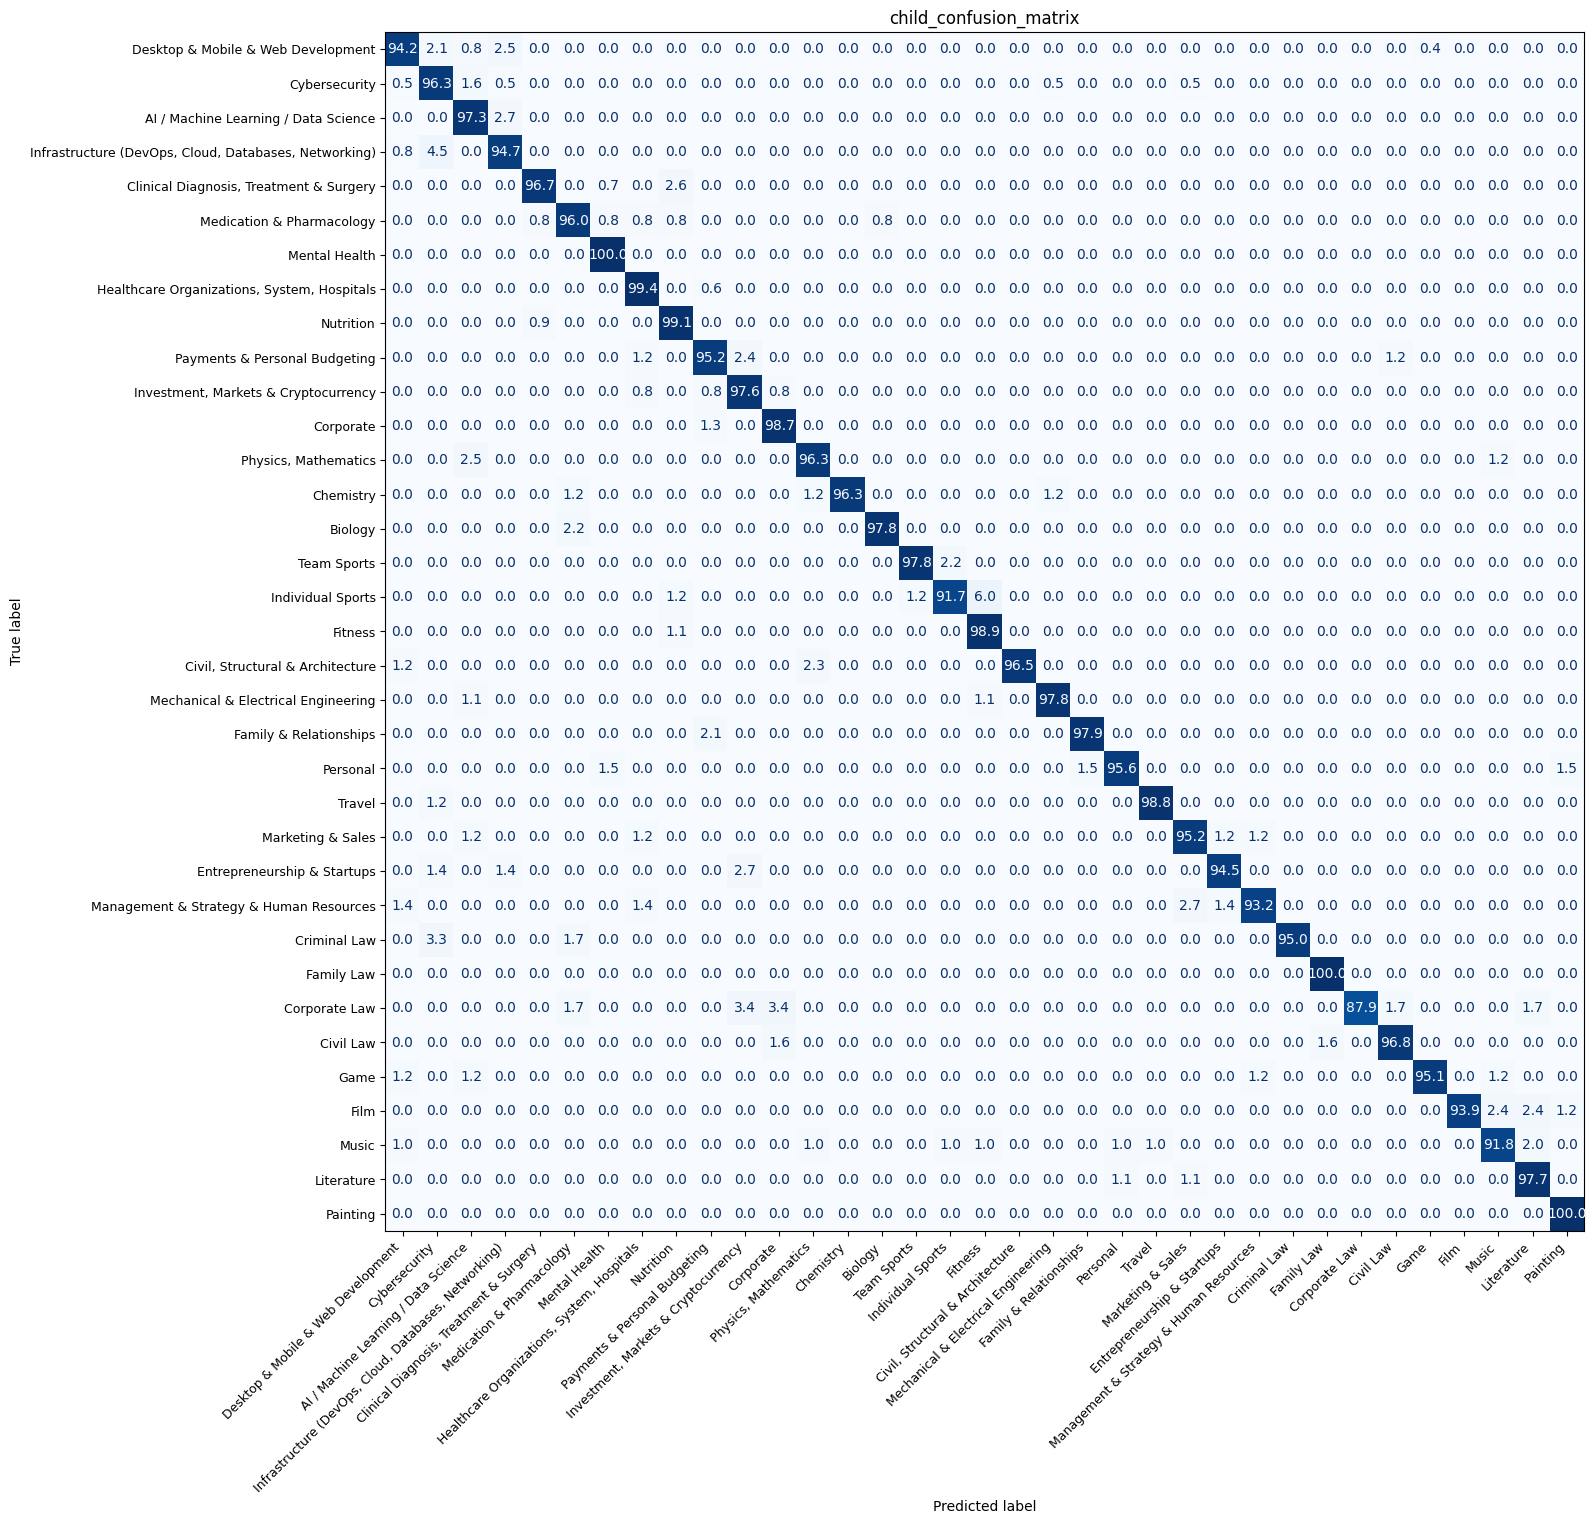

In [ ]:
plot_child_confusion_matrix(
    y_test_filtered,
    y_pred_filtered,
    label_order,
)

In [ ]:
import json
import pandas as pd

# Copy only confident test samples
df_filtered = df_test.iloc[np.where(confident_mask)[0]].copy()

# Add prediction
df_filtered["predicted_label"] = y_pred_filtered

# Add confidence
df_filtered["confidence"] = confidence[confident_mask]

# Save
df_filtered.to_json(
    "filtered_test_results.json",
    orient="records",
    force_ascii=False,
    indent=2,
)

print(f"Saved {len(df_filtered)} samples")
print("Saved to: filtered_test_results.json")

ValueError: Length of values (3595) does not match length of index (2691)

In [ ]:
import json

# --------------------------------------------------
# Paths
# --------------------------------------------------

INPUT_PATH = "/content/filtered_test_results.json"
OUTPUT_PATH = "classifier_results_real_test.json"


# --------------------------------------------------
# Load input JSON
# --------------------------------------------------

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# --------------------------------------------------
# Convert
# --------------------------------------------------

output = []

for shuffled_index, sample in enumerate(data):

    predicted_id = sample["predicted_label"]

    converted_sample = {
        "shuffled_index": shuffled_index,
        "text": sample["text"],
        "label": sample["label"],
        "generation_group": "Null",
        "llm_prediction": label_order[predicted_id],
    }

    output.append(converted_sample)


# --------------------------------------------------
# Save
# --------------------------------------------------

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Saved {len(output)} samples to {OUTPUT_PATH}")